In [ ]:
!pip install CBFV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 9.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/new_dataset.xlsx')

In [ ]:
import CBFV
from CBFV import composition

In [ ]:
data = df[["formula", "Temperature", "target"]]

In [ ]:
x1 ,y1, feature, skipped = composition.generate_features(data, elem_prop='magpie', drop_duplicates= False, extend_features= True )

Processing Input Data: 100%|██████████| 340/340 [00:00<00:00, 20627.23it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 340/340 [00:00<00:00, 7319.30it/s]

	Creating Pandas Objects...


# Train - Test Split (80-20)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x1, y1, test_size= 0.2, random_state=42 )

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import  GridSearchCV

In [ ]:
#Define the model
gbr = GradientBoostingRegressor(random_state=42);

In [ ]:
# Instantiate the standard scaler
scaler = StandardScaler()
# zero mean and unit variance
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# Set the hyperparameters grid to search
param_grid ={
    'learning_rate' : [0.1, 0.2, 0.5],
    'n_estimators' : [50,100,200],
    'min_samples_split' : [2,5,10],
    'max_depth' : [10,20,30],
}

In [ ]:
grid_search = GridSearchCV(gbr,param_grid=param_grid, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)

In [ ]:
grid_search.fit(X_train_scaled, Y_train)

GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2, 0.5],
                         'max_depth': [10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [ ]:
best_model = grid_search.best_estimator_
best_hyperparameteres = grid_search.best_params_

#print the details of best model
print(f"Best Model: {best_model}")
print(f"Best Hyperparameters : {best_hyperparameteres}")

Best Model: GradientBoostingRegressor(learning_rate=0.2, max_depth=10, min_samples_split=10,
                          n_estimators=50, random_state=42)
Best Hyperparameters : {'learning_rate': 0.2, 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


In [ ]:
# Predict the output
y_pred = best_model.predict(X_test_scaled)

In [ ]:
#Evaluate the model
rmse = root_mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test,y_pred)

print(f"Root Mean Square Error without scaling: {rmse}")
print(f"R2 for without scaling: {r2}")

Root Mean Square Error without scaling: 29.84077360663344
R2 for without scaling: 0.8263119484570816


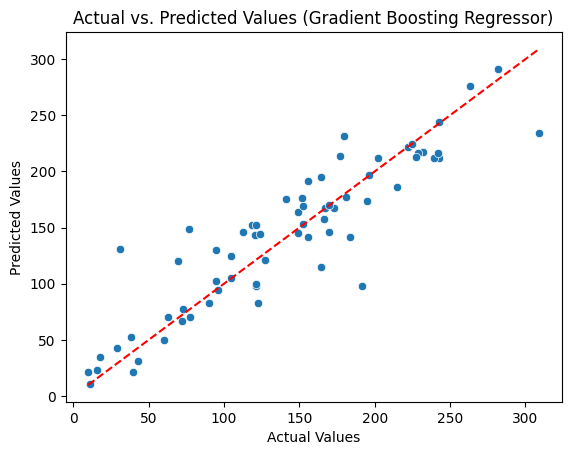

In [ ]:
# Visualize the results
sns.scatterplot(x=Y_test, y=y_pred)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')  # 45-degree line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Gradient Boosting Regressor)")
plt.show()


In [ ]:
Y_pred_train = best_model.predict(X_train_scaled)

In [ ]:
# Evaluate the model
rmse_train = root_mean_squared_error(Y_train, Y_pred_train)
r2_train = r2_score(Y_train,Y_pred_train)

print(f"Mean Square Error without scaling: {rmse_train}")
print(f"R2 for without scaling: {r2_train}")

Mean Square Error without scaling: 11.255125496964952
R2 for without scaling: 0.9749588964032684


# Bayesian Optimization

In [ ]:
from scipy.stats import norm

In [ ]:
# DETERMINING the mean and standard Deviation using bootstrap sampling with 100 bootstrap samples

def bootstrap_estimator(model, X_train, y_train, X_test, n_iter=100):
    bootstrap_preds = np.zeros([len(X_test), n_iter])

    index = np.arange(X_train.shape[0])

    ## set the seed to repeat the boot strapping
    np.random.seed(20)
    for i in range(n_iter):
        #sample from X_train, y_train
        index_sampled = np.random.choice(index, size=X_train.shape[0], replace=True)

        X_train_sample = pd.DataFrame(X_train).iloc[index_sampled.tolist(),:]
        # Access y_train using .iloc to ensure positional indexing
        y_train_sample = y_train.iloc[index_sampled]

        #model.fit(X_train_sample, y_train_sample)
        model.fit(X_train_sample, y_train_sample)

        #pred_i = model.predict(X_test)

        pred_i = model.predict(X_test)
        #print('pred_i:', pred_i)

        bootstrap_preds[:,i] = pred_i
        #print(bootstrap_preds)

    return(bootstrap_preds.mean(1),bootstrap_preds.std(1))

## Expection Improvement Calculation


def Expected_Improvement(X_test, X_train_all, y_train_all, model, xi=0.01):
    mu_x, sigma_x = bootstrap_estimator(model, X_train_all, y_train_all, X_test, n_iter=100)
    mu_max = np.max(y_train_all)
    # mu_max is the highest material property value in the training data which is at 24 deg C
    # therefore the candidate search space is choosen at 24 deg C

    diff = (mu_x-mu_max-xi)
    z = diff/sigma_x
    ei = diff*norm.cdf(z)+sigma_x*norm.pdf(z)
    ei[sigma_x == 0.0] = 0.
    return(ei,mu_x,sigma_x)

In [ ]:
mean , std  = bootstrap_estimator(best_model, X_train, Y_train, X_test, n_iter=100)

print(pd.DataFrame([mean,std]))

mean_train , std_train  = bootstrap_estimator(best_model, X_train, Y_train, X_train, n_iter=100)


          0           1           2           3           4          5   \
0  51.578212  123.232094  139.975244  119.460121  167.219477  98.883683   
1   4.854054   30.291977   25.718864   16.618442    3.499100   4.998575   

           6           7          8           9   ...          58         59  \
0  263.498555  214.936226  49.047875  228.619107  ...  166.485277  28.513720   
1   27.779471    5.916688  18.792041   23.543573  ...   11.412447  14.647471   

           60         61          62          63         64          65  \
0  127.355542  87.791242  219.526064  178.195334  95.950985  189.807044   
1   48.388326  34.049891    8.151017   16.152618  11.654307   49.886260   

           66         67  
0  102.984524  23.980094  
1    9.864974  10.043782  

[2 rows x 68 columns]


### Plotting the uncertainties for the test data

r2 score test data: 0.8172203645776048
r2 score train data: 0.9611643970499834


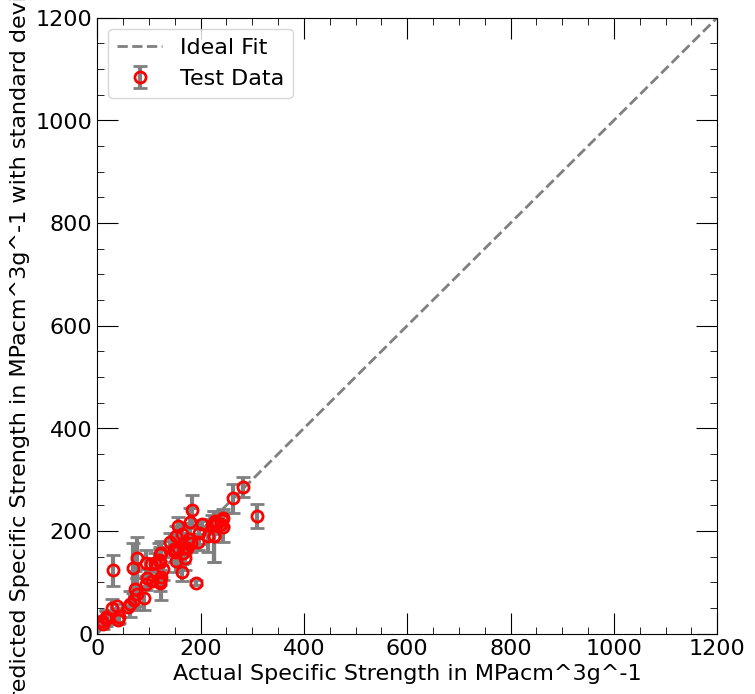

In [ ]:
plt.figure(figsize=(8,8))

plt.errorbar(Y_test,mean,yerr=std,ecolor = 'grey',mfc='None', mec='red',mew=2,elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Test Data')

plt.xlabel('Actual Specific Strength in MPacm^3g^-1',fontsize=16)
plt.ylabel('Predicted Specific Strength in MPacm^3g^-1 with standard deviation',fontsize=16)
plt.axline((0, 0), (1200, 1200), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)
plt.xlim(0,1200)
plt.ylim(0,1200)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')

print('r2 score test data:',r2_score(Y_test,mean))
print('r2 score train data:',r2_score(Y_train,mean_train))
# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

### Plotting the uncertainties for the train data

r2 score test data: 0.8172203645776048
r2 score train data: 0.9611643970499834


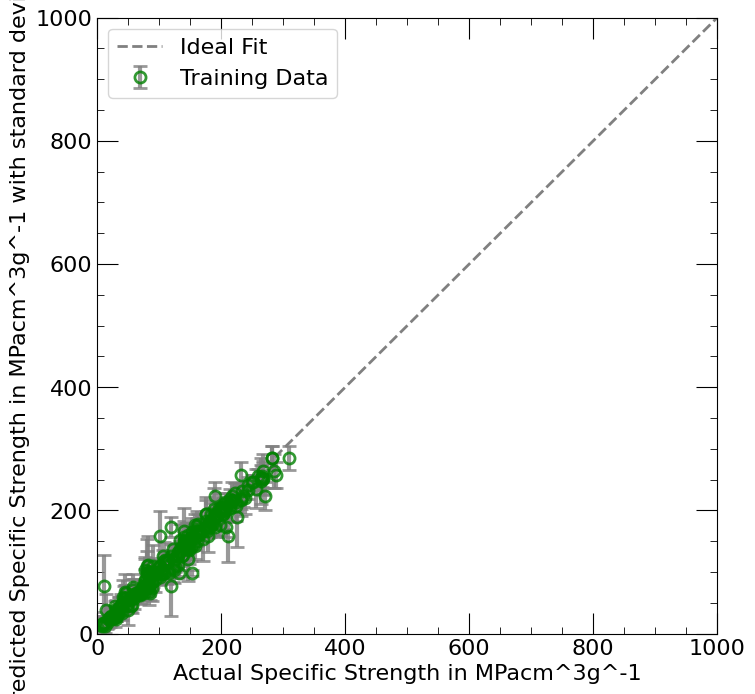

In [ ]:
plt.figure(figsize=(8,8))

plt.errorbar(Y_train,mean_train,yerr=std_train,mfc='None',mec='green',mew=2,ecolor = 'grey',alpha=0.8, elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Training Data')
plt.xlabel('Actual Specific Strength in MPacm^3g^-1',fontsize=16)
plt.ylabel('Predicted Specific Strength in MPacm^3g^-1 with standard deviation',fontsize=16)
plt.axline((0, 0), (1000, 1000), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


plt.xlim(0,1000)
plt.ylim(0,1000)
print('r2 score test data:',r2_score(Y_test,mean))
print('r2 score train data:',r2_score(Y_train,mean_train))

# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

### Reading .csv file of composition (candidate search space)  and converting weight percent to atom percent

In [ ]:
df_test_composition = pd.read_csv('/content/compositions_test_candidates_4_allcombinations.csv')
df_test_total = df_test_composition[['formula','Temperature','target']]

df_test_total.head()



,formula,Temperature,target
0,Nb97Al1Co1Cr1,24,0
1,Nb96Al1Co1Cr2,24,0
2,Nb95Al1Co1Cr3,24,0
3,Nb94Al1Co1Cr4,24,0
4,Nb93Al1Co1Cr5,24,0


In [ ]:
print(len(df_test_total))
df_test_final = df_test_total
df_test_final.tail()

100000


,formula,Temperature,target
99995,Nb91Al4Co4V1,24,0
99996,Nb90Al4Co4V2,24,0
99997,Nb89Al4Co4V3,24,0
99998,Nb88Al4Co4V4,24,0
99999,Nb87Al4Co4V5,24,0


In [ ]:
df_test_final = df_test_final.head(1000)
print(len(df_test_final))

1000


### Generate Features for the search space using CBFV

In [ ]:
X_test_comp, y_test_comp, formulae_test_comp, skipped_train = composition.generate_features(df_test_final,elem_prop='magpie',drop_duplicates=False,extend_features=True)

Processing Input Data: 100%|██████████| 1000/1000 [00:00<00:00, 21569.09it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 1000/1000 [00:00<00:00, 10429.47it/s]


	Creating Pandas Objects...


In [ ]:
print('maximum value of the Specific Strength in the experimental data:',Y_train.max())

maximum value of the Specific Strength in the experimental data: 309.4366197183099


In [ ]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(x1)
X_test_comp_scaled  = scaler.transform(X_test_comp)

In [ ]:
mean_train_all , std_train_all  = bootstrap_estimator(best_model, X_Scaled , y1, X_Scaled, n_iter=100)


In [ ]:
ei,predicted_property,std = Expected_Improvement(X_test_comp_scaled, X_Scaled ,y1,best_model,xi=0.01)


In [ ]:
df_predict = pd.DataFrame({"ei":ei, "std":std})
df_predict_final = df_test_final.join(df_predict)
df_predict_final["target"] = predicted_property
df_predict_final_sorted = df_predict_final.sort_values('ei',ascending=False)
df_predict_final_sorted


,formula,Temperature,target,ei,std
16,Nb81Al1Co1Cr17,24,188.280576,1.987420e-04,30.154394
784,Nb81Al2Co7Cr10,24,197.278381,1.337643e-04,27.454366
641,Nb80Al2Co1Cr17,24,192.394062,1.267745e-04,28.508832
15,Nb82Al1Co1Cr16,24,186.298472,1.258693e-04,29.905147
760,Nb81Al2Co6Cr11,24,196.685512,1.232012e-04,27.475907
...,...,...,...,...,...
503,Nb74Al1Co21Cr4,24,196.565772,6.638241e-11,17.200536
481,Nb72Al1Co20Cr7,24,196.169396,2.168458e-11,16.853593
480,Nb73Al1Co20Cr6,24,195.902053,1.940306e-11,16.853597
505,Nb72Al1Co21Cr6,24,195.915226,1.817437e-11,16.828890


In [ ]:
#dup = data.drop_duplicates(subset=['formula', 'Temperature'], keep='first')
df = data.sort_values('target', ascending=False)
df = df[df['Temperature'] <= 25]

# Clean the relevant columns
df['Temperature'] = df['Temperature'].round(2)
#df['formula'] = df['formula'].str.strip().str.lower()

# Drop duplicates
od_sorted = df.drop_duplicates(subset=['Temperature', 'formula'], keep='first')
print(len(od_sorted))


121


In [ ]:
od_max_5 = od_sorted.head()
print("Top 5 performers")
od_max_5


Top 5 performers


,formula,Temperature,target
64,AlMo0.5NbTa0.5TiZr,25.0,309.436620
25,Al0.5Mo0.5NbTa0.5TiZr,25.0,309.210526
40,AlCr0.5NbTiV,25.0,288.135593
179,Hf0.75NbTa0.5Ti1.5Zr1.25,-268.8,284.523810
189,HfMo0.5NbSi0.3TiV0.5,25.0,270.126582


In [ ]:
od_min_5 = od_sorted.tail()
print("Low 5 performers")
od_min_5

Low 5 performers


,formula,Temperature,target
148,Hf0.4Nb1.54Ta1.54Ti0.89Zr0.64,25.0,79.038462
307,MoNbTaW,25.0,77.226277
263,HfTa0.5TiZr,25.0,74.468085
213,HfNb0.18Ta0.18Ti1.27Zr,25.0,63.529412
262,HfTa0.4TiZr,25.0,43.478261


In [ ]:
ei_top_5 = df_predict_final_sorted.head()
ei_top_5

,formula,Temperature,target,ei,std
16,Nb81Al1Co1Cr17,24,188.280576,0.000199,30.154394
784,Nb81Al2Co7Cr10,24,197.278381,0.000134,27.454366
641,Nb80Al2Co1Cr17,24,192.394062,0.000127,28.508832
15,Nb82Al1Co1Cr16,24,186.298472,0.000126,29.905147
760,Nb81Al2Co6Cr11,24,196.685512,0.000123,27.475907


In [ ]:
ei_top_5 = ei_top_5[["formula","Temperature","target"]]
ei_top_5

,formula,Temperature,target
16,Nb81Al1Co1Cr17,24,188.280576
784,Nb81Al2Co7Cr10,24,197.278381
641,Nb80Al2Co1Cr17,24,192.394062
15,Nb82Al1Co1Cr16,24,186.298472
760,Nb81Al2Co6Cr11,24,196.685512


In [ ]:
print("Top 5 Performers (Max Response):")
print(od_max_5[['formula','Temperature', 'target']])  # replace 'formula' and 'response' with actual column names if different

print("\nLow 5 Performers (Min Response):")
print(od_min_5[['formula','Temperature', 'target']])

print("\nTop 5 EI:")
print(ei_top_5[['formula','Temperature', 'target']])


Top 5 Performers (Max Response):
                      formula  Temperature      target
64         AlMo0.5NbTa0.5TiZr         25.0  309.436620
25      Al0.5Mo0.5NbTa0.5TiZr         25.0  309.210526
40               AlCr0.5NbTiV         25.0  288.135593
179  Hf0.75NbTa0.5Ti1.5Zr1.25       -268.8  284.523810
189      HfMo0.5NbSi0.3TiV0.5         25.0  270.126582

Low 5 Performers (Min Response):
                           formula  Temperature     target
148  Hf0.4Nb1.54Ta1.54Ti0.89Zr0.64         25.0  79.038462
307                        MoNbTaW         25.0  77.226277
263                    HfTa0.5TiZr         25.0  74.468085
213         HfNb0.18Ta0.18Ti1.27Zr         25.0  63.529412
262                    HfTa0.4TiZr         25.0  43.478261

Top 5 EI:
            formula  Temperature      target
16   Nb81Al1Co1Cr17           24  188.280576
784  Nb81Al2Co7Cr10           24  197.278381
641  Nb80Al2Co1Cr17           24  192.394062
15   Nb82Al1Co1Cr16           24  186.298472
760  Nb81Al2C

In [ ]:
x_od_max5, y_od_max5,feature_max_5, skip_max_5  = composition.generate_features(od_max_5, elem_prop='magpie',drop_duplicates=False, extend_features=True)

Processing Input Data: 100%|██████████| 5/5 [00:00<00:00, 9194.00it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 5/5 [00:00<00:00, 4092.00it/s]

	Creating Pandas Objects...


In [ ]:
x_od_min5, y_od_min5,feature_min_5, skip_min_5  = composition.generate_features(od_min_5, elem_prop='magpie',drop_duplicates=False, extend_features=True)

Processing Input Data: 100%|██████████| 5/5 [00:00<00:00, 4501.29it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 5/5 [00:00<00:00, 3736.24it/s]

	Creating Pandas Objects...


In [ ]:
x_ei_top5, y_ei_top5,feature_top_5, skip_top_5  = composition.generate_features(ei_top_5, elem_prop='magpie',drop_duplicates=False, extend_features=True)

Processing Input Data: 100%|██████████| 5/5 [00:00<00:00, 6219.31it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 5/5 [00:00<00:00, 4190.95it/s]

	Creating Pandas Objects...


In [ ]:
print("x_od_max5:", x_od_max5.shape)
print("x_od_min5:", x_od_min5.shape)
print("x_ei_top5:", x_ei_top5.shape)



x_od_max5: (5, 133)
x_od_min5: (5, 133)
x_ei_top5: (5, 133)


In [ ]:
# Feature generation with temperature for each group separately
'''def get_features_with_temp(df, magpie_features_df):  # Add magpie_features_df as an argument

    """Combines Magpie features with temperature and engineered temp-based features."""

    # Ensure temperature is aligned with the same index
    temperature = df["Temperature"]

    # Base features
    combined = magpie_features_df.copy()
    combined["Temperature"] = temperature

    # Example temp-based interaction features
    if "mean_Electronegativity" in combined.columns:
        combined["EN_Temp_Product"] = combined["mean_Electronegativity"] * temperature
        combined["EN_Temp_Ratio"] = combined["mean_Electronegativity"] / (temperature + 1e-6)  # avoid div by zero

    if "mean_AtomicRadius" in combined.columns:
        combined["Radius_Temp_Product"] = combined["mean_AtomicRadius"] * temperature
        combined["Radius_Temp_Ratio"] = combined["mean_AtomicRadius"] / (temperature + 1e-6)

    # You can add more interaction features here if needed
    return combined


# Example usage, assuming x_od_max5, x_od_min5, x_ei_top5 store the Magpie features:
x_od_max5 = get_features_with_temp(od_max_5, pd.DataFrame(x_od_max5, index=od_max_5.index))
x_od_min5 = get_features_with_temp(od_min_5, pd.DataFrame(x_od_min5, index=od_min_5.index))
x_ei_top5 = get_features_with_temp(ei_top_5, pd.DataFrame(x_ei_top5, index=ei_top_5.index))

# Check again
print(x_od_max5.shape, x_od_min5.shape, x_ei_top5.shape)'''

(5, 133) (5, 133) (5, 133)


In [ ]:
# Step 1: Combine the standardized feature sets
X_combined = np.vstack([x_od_max5, x_od_min5, x_ei_top5])

In [ ]:
#standardize the dataset
scaler = StandardScaler()
X_comb_std = scaler.fit_transform(X_combined)

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
n_components = min(10, X_comb_std.shape[0] - 1, X_comb_std.shape[1])
print(f"PCA will use {n_components} components")
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_comb_std)


PCA will use 10 components


In [ ]:
print("X_std shape:", X_comb_std.shape)
print("X_combined shape:", X_combined.shape)
print("np.isnan(X_std).sum():", np.isnan(X_comb_std).sum())
print("np.isnan(X_combined).sum():", np.isnan(X_combined).sum())


X_std shape: (15, 133)
X_combined shape: (15, 133)
np.isnan(X_std).sum(): 0
np.isnan(X_combined).sum(): 0


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_comb_std)

# t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
'''pca = PCA(n_components=2)
X_comb_std = pca.fit_transform(X_comb_std)'''

In [ ]:
'''tsne = TSNE(n_components=2, perplexity=3, random_state=42, n_iter=1000)
X_comb_tsne = tsne.fit_transform(X_comb_pca)'''

'tsne = TSNE(n_components=2, perplexity=3, random_state=42, n_iter=1000)\nX_comb_tsne = tsne.fit_transform(X_comb_pca)'

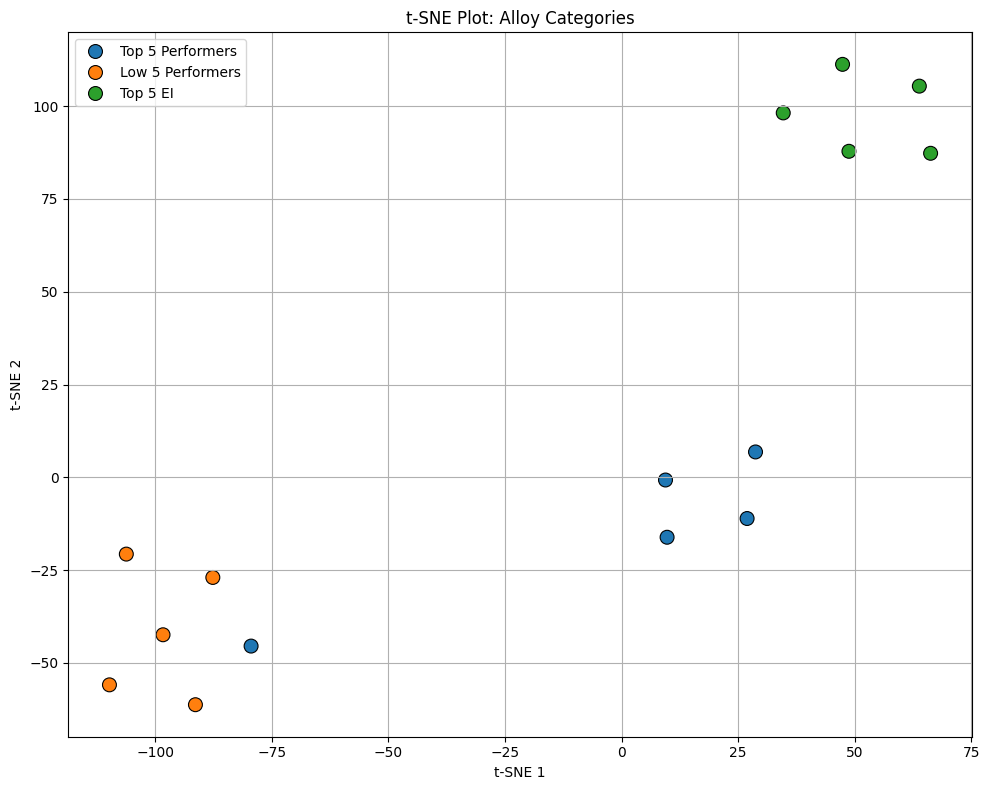

In [ ]:
labels = (['Top 5 Performers'] * len(x_od_max5) +
          ['Low 5 Performers'] * len(x_od_min5) +
          ['Top 5 EI'] * len(x_ei_top5))



# Create DataFrame
dfp1 = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
dfp1["Category"] = labels


# Plotting
plt.figure(figsize=(10, 8))
palette = {"Top 5 Performers": "#1f77b4", "Low 5 Performers": "#ff7f0e", "Top 5 EI": "#2ca02c"}

sns.scatterplot(
    data=dfp1,
    x="TSNE1",
    y="TSNE2",
    hue="Category",
    palette=palette,
    s=100,
    edgecolor='black',
    marker='o'  # circle marker
)



# Final plot settings
plt.title("t-SNE Plot: Alloy Categories")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title='', loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Create group labels
labels = (
    ['Top 5 performers'] * len(x_od_max5) +
    ['Low 5 performers'] * len(x_od_min5) +
    ['Top 5 EI'] * len(x_ei_top5)
)

# Step 3: Run t-SNE once on combined features
tsne = TSNE(n_components=2, perplexity=3, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_comb_std)
colors = {'Top 5 performers': 'yellow', 'Low 5 performers': 'red', 'Top 5 EI': 'blue'}

plt.figure(figsize=(8, 6))
for label in np.unique(labels):
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, color=colors[label], s=100, edgecolors='k')


plt.title("t-SNE Visualization of Alloy Groups")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'x_od_max5' is not defined

In [ ]:
len(x_ei_top5)

5